# Text Analysis

## Importing Libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
import pickle
import re
import numpy as np



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\haseeeb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\haseeeb\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\haseeeb\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\haseeeb\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Loading datasets

In [6]:
df=pd.read_csv("hasi.csv",usecols=["text","sentiment"])

In [7]:
df = df[df["sentiment"] != "neutral"]

## Encoding Sentiment Columns

In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["sentiment"]=le.fit_transform(df["sentiment"])

## Virtualization of Percentage of Positive and Negative values

Text(0.5, 1.0, 'label distribution')

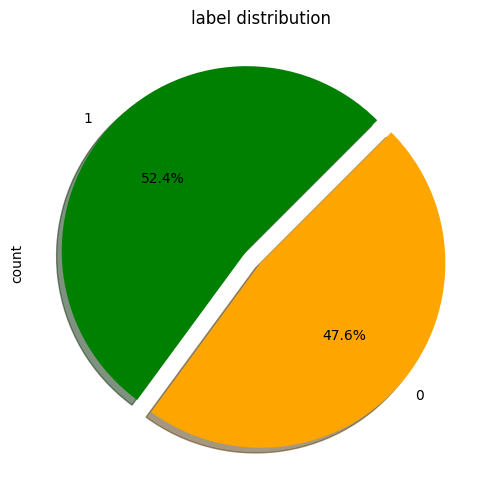

In [9]:
plt.figure(figsize=(10,6))
colors = ['green', 'orange','red']
df['sentiment'].value_counts().plot(kind='pie', autopct='%.1f%%',shadow = True,colors = colors,startangle = 45,
                 explode=(0.1, 0)) # Changed explode to have 3 values
plt.title('label distribution')

## Feature Enginnering

In [10]:
stopwords_set = set(stopwords.words('english'))
emoji_pattern = re.compile('(?::|;|=)(?:-)?(?:\)|\(|D|P)')

def preprocessing(text):
    text = re.sub('<[^>]*>', '', text)
    emojis = emoji_pattern.findall(text)
    text = re.sub('[\W+]', ' ', text.lower()) + ' '.join(emojis).replace('-', '')

    prter = PorterStemmer()
    text = [prter.stem(word) for word in text.split() if word not in stopwords_set]

    return " ".join(text)

## Adding Cleaned Data in Original Data set

In [11]:
df['text'] = df['text'].apply(lambda x: preprocessing(x))

In [12]:
df.head(3)

,text,sentiment
1,shanghai also realli excit precis skyscrap gal...,1
2,recess hit veroniqu branquinho quit compani shame,0
3,happi bday,1


## Analysising Dataset

In [13]:
df.shape

(2104, 2)

In [14]:
df["sentiment"].value_counts()

sentiment
1    1103
0    1001
Name: count, dtype: int64

<Axes: title={'center': 'Sentiments Count'}, xlabel='sentiment'>

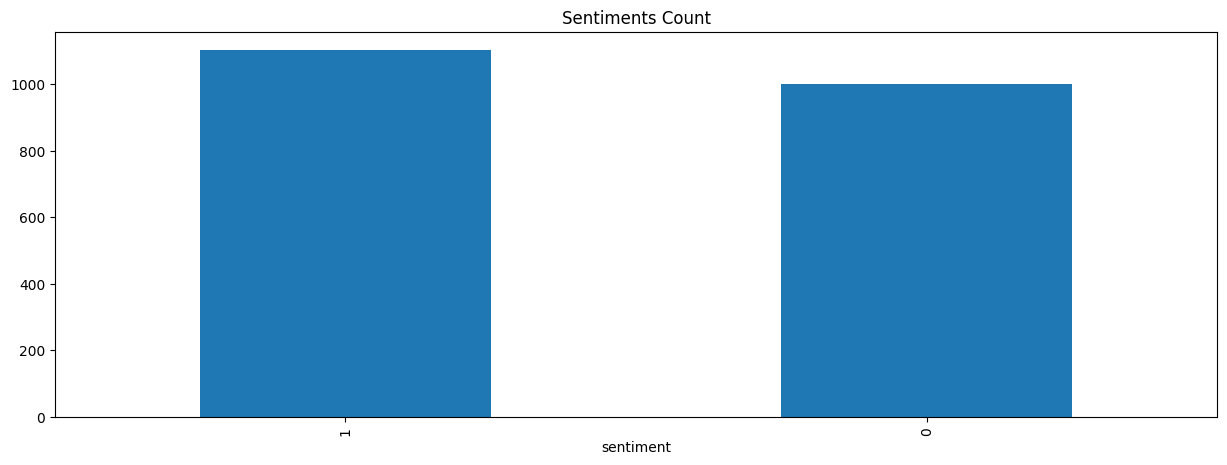

In [15]:
df["sentiment"].value_counts().plot(kind="bar", title="Sentiments Count", figsize=(15,5))


In [16]:
df["sentiment"].values[2]

np.int64(1)

## Checking 15 Common repeative Positive and Neagtive Words from datasets

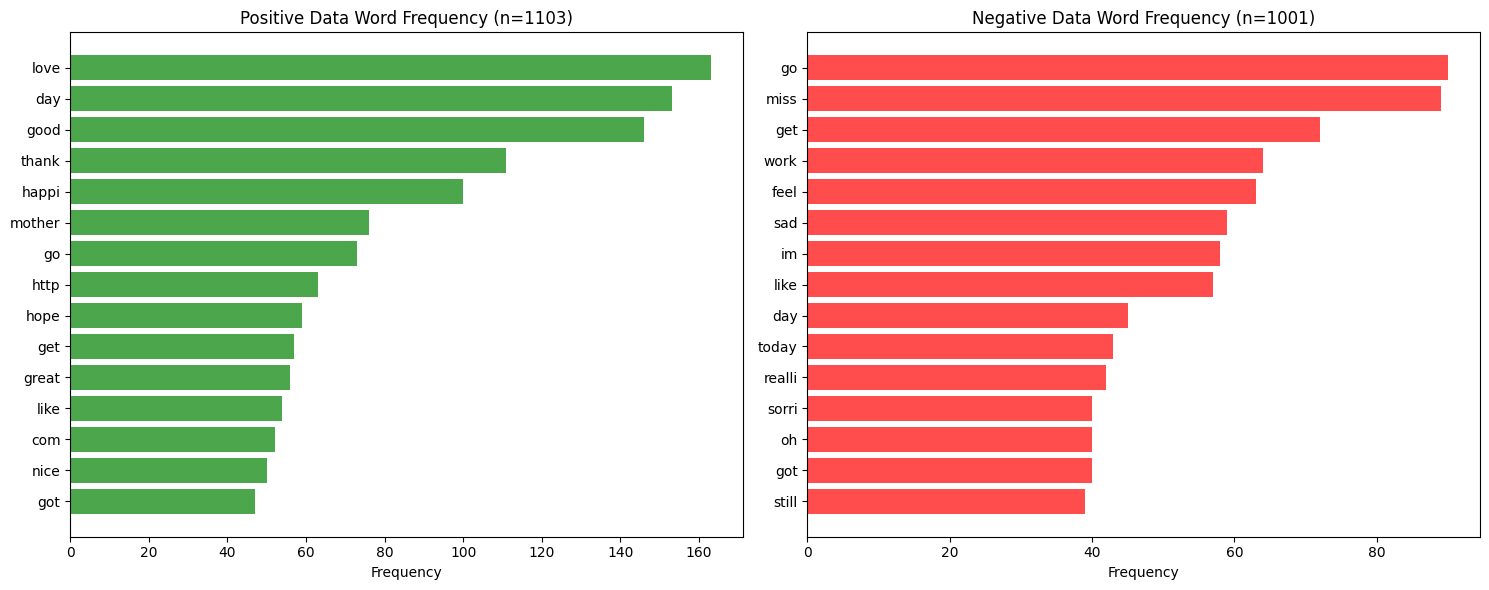

In [17]:

# Fix the data extraction
positivedata = df[df['sentiment'] == 1]
positivedata = positivedata['text']  # Make sure 'text' column exists

negdata = df[df['sentiment'] == 0]
negdata = negdata['text']

import matplotlib.pyplot as plt  # Fix: use plt.subplots, not sns.subplots
import seaborn as sns
from collections import Counter

# Positive data
positivedata_words = ' '.join(positivedata.dropna()).split()  # Handle NaN values
positivedata_word_counts = Counter(positivedata_words)
positivedata_common_words = positivedata_word_counts.most_common(15)

# Negative data
negdata_words = ' '.join(negdata.dropna()).split()  # Handle NaN values
negdata_word_counts = Counter(negdata_words)
negdata_common_words = negdata_word_counts.most_common(15)

# Plotting - Fix: use plt.subplots instead of sns.subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Positive data word frequency
if positivedata_common_words:
    words, counts = zip(*positivedata_common_words)
    axes[0].barh(range(len(words)), counts, align='center', color='green', alpha=0.7)
    axes[0].set_yticks(range(len(words)))
    axes[0].set_yticklabels(words)
    axes[0].set_title(f'Positive Data Word Frequency (n={len(positivedata)})')
    axes[0].set_xlabel('Frequency')
    axes[0].invert_yaxis()  # Show most frequent at top

# Negative data word frequency
if negdata_common_words:
    words, counts = zip(*negdata_common_words)
    axes[1].barh(range(len(words)), counts, align='center', color='red', alpha=0.7)
    axes[1].set_yticks(range(len(words)))
    axes[1].set_yticklabels(words)
    axes[1].set_title(f'Negative Data Word Frequency (n={len(negdata)})')
    axes[1].set_xlabel('Frequency')
    axes[1].invert_yaxis()  # Show most frequent at top

plt.tight_layout()
plt.show()

## Vectoriztion of Cleand Data columns

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(strip_accents=None,lowercase=False,preprocessor=None,use_idf=True,norm='l2',smooth_idf=True,ngram_range=(1,3),max_features=2000)
y=df.sentiment.values
X=tfidf.fit_transform(df.text)


## Train Test Spilt

In [19]:
from sklearn.model_selection import train_test_split
X_train , X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Imbalancing Sentiment Column to avoid model basied

In [20]:
from imblearn.over_sampling import BorderlineSMOTE

borderline_smote = BorderlineSMOTE(random_state=42)
X_train_re,y_train_re=borderline_smote.fit_resample(X_train,y_train)

## Sentiment column And After resampling

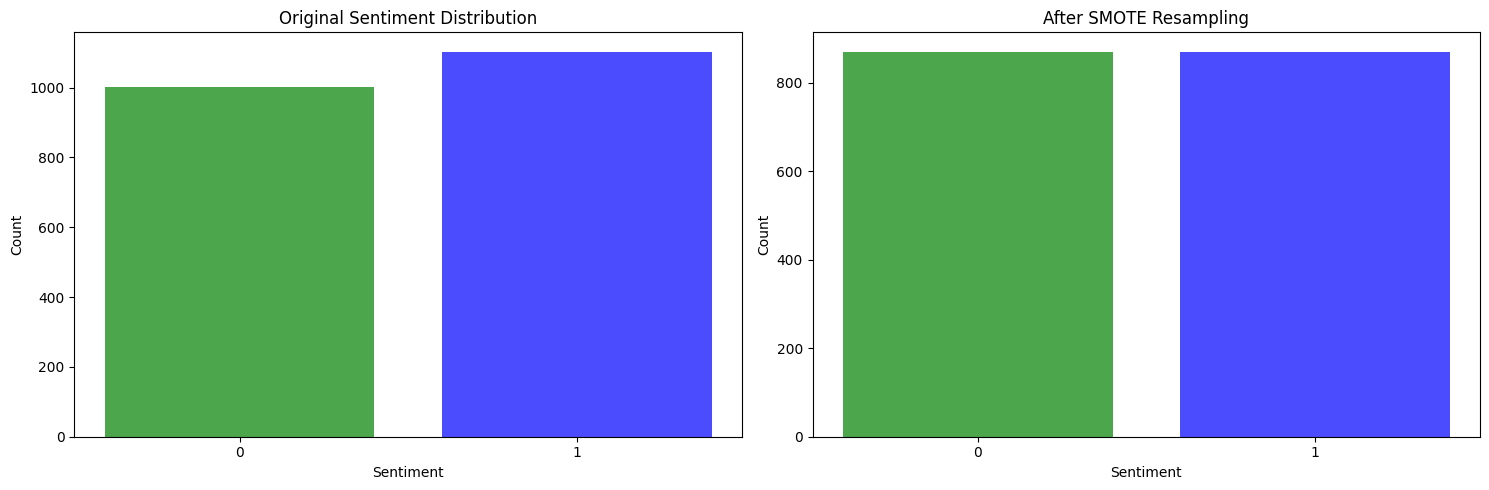

In [21]:
sentiments = df['sentiment'].value_counts().index
counts = df['sentiment'].value_counts().values


sentiments1 = pd.Series(y_train_re).value_counts().index
counts1 = pd.Series(y_train_re).value_counts().values

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# First subplot - Original data
axs[0].bar(sentiments, counts, color=['blue', 'green', 'red'], alpha=0.7)
axs[0].set_title('Original Sentiment Distribution')
axs[0].set_xlabel('Sentiment')
axs[0].set_ylabel('Count')
axs[0].set_xticks(sentiments)

# Second subplot - Resampled data (Fix: use axs[1], not axs[0])
axs[1].bar(sentiments1, counts1, color=['blue', 'green', 'red'], alpha=0.7)
axs[1].set_title('After SMOTE Resampling')  # Fix: Different title
axs[1].set_xlabel('Sentiment')
axs[1].set_ylabel('Count')
axs[1].set_xticks(sentiments1)

plt.tight_layout()
plt.show()

## Model selection

In [22]:
from sklearn.linear_model import LogisticRegressionCV
clf=LogisticRegressionCV(cv=9,scoring='accuracy',random_state=0,n_jobs=-1,verbose=4,max_iter=1000).fit(X_train_re,y_train_re)
y_pred = clf.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   9 | elapsed:    6.5s remaining:    8.2s
[Parallel(n_jobs=-1)]: Done   7 out of   9 | elapsed:    6.6s remaining:    1.8s
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:    6.7s finished


In [23]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(f'classification_report: {classification_report(y_test,y_pred)}')
print(f'confusion_matrix: {confusion_matrix(y_test,y_pred)}')
print(f'accuracy_score: {accuracy_score(y_test,y_pred)}')

# Model Accuracy, how often is the classifier correct?


classification_report:               precision    recall  f1-score   support

           0       0.82      0.88      0.85       188
           1       0.90      0.85      0.87       233

    accuracy                           0.86       421
   macro avg       0.86      0.86      0.86       421
weighted avg       0.86      0.86      0.86       421

confusion_matrix: [[165  23]
 [ 36 197]]
accuracy_score: 0.8598574821852731


## Heat map of Model Confussion Matrix

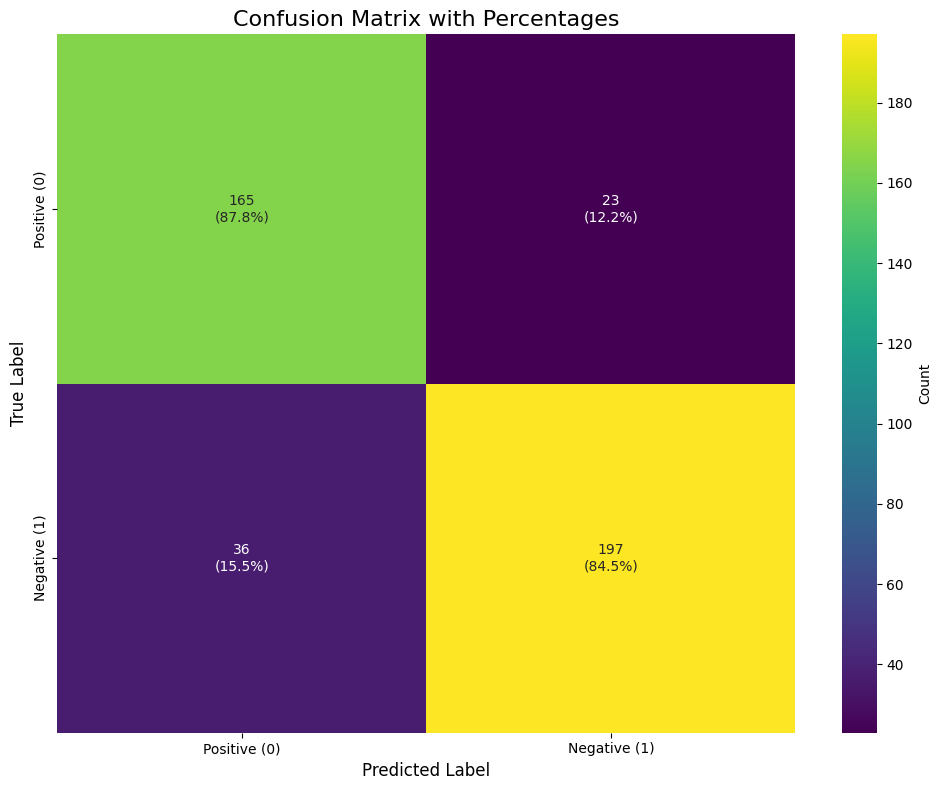

In [24]:
plt.figure(figsize=(10, 8))

cm = confusion_matrix(y_test, y_pred)
# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create annotations with both counts and percentages
annotations = []
for i in range(cm.shape[0]):
    row = []
    for j in range(cm.shape[1]):
        row.append(f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)')
    annotations.append(row)

sns.heatmap(cm, annot=annotations, fmt='', cmap='viridis',
            xticklabels=[ 'Positive (0)', 'Negative (1)'],
            yticklabels=[ 'Positive (0)', 'Negative (1)'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix with Percentages', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


## Exporting Model in pickel file

In [ ]:
pickle.dump(clf, open('../Models/model.pkl', 'wb'))
pickle.dump(tfidf, open('../Models/tfidf.pkl', 'wb'))

## Testing

In [ ]:
def precdiction(comment):
  comment_preprocessing=preprocessing(comment)
  vectorized_comment=tfidf.transform([comment_preprocessing])
  prediction=clf.predict(vectorized_comment)
  return prediction

In [ ]:
result=precdiction("I hate you")
print(result.dtype)

In [ ]:
if result==0:
  print("negative")
else:
    print("postive")